# Experimentations

## Imports

In [5]:
import io
import os
import zipfile

import cv2
import numpy as np
import requests
import torch
from diffusers import (
    DiffusionPipeline,
    StableDiffusionImg2ImgPipeline,
    StableDiffusionPipeline,
)
from dotenv import load_dotenv
from huggingface_hub import hf_hub_download, snapshot_download
from PIL import Image

## Global Variables

In [ ]:
load_dotenv(dotenv_path="../../.env")

SD2_1_MODEL_PATH = os.getenv("SD2_1_MODEL_PATH")
MINECRAFT_TEXTURE_LORA_MODEL_PATH = os.getenv("MINECRAFT_TEXTURE_LORA_MODEL_PATH")
ALL_IN_ONE_MODEL_PATH = os.getenv("ALL_IN_ONE_MODEL_PATH")
SDXL_MODEL_PATH = os.getenv("SDXL_MODEL_PATH")
PLIXEL_MINECRAFT_MODEL_PATH = os.getenv("PLIXEL_MINECRAFT_MODEL_PATH")
PRETRAINED_MODEL_PATH_HOST = os.getenv("PRETRAINED_MODEL_PATH_HOST")
MINETEXTURE_CHECKPOINTS_OUTPUT_FOLDER_PATH = os.getenv(
    "MINETEXTURE_CHECKPOINTS_OUTPUT_FOLDER_PATH"
)

DEFAULT_TEXTURE_PACK_FOLDER_PATH = os.getenv("DEFAULT_TEXTURE_PACK_FOLDER_PATH")
DEFAULT_TEXTURE_PACK_ZIP_PATH = os.getenv("DEFAULT_TEXTURE_PACK_ZIP_PATH")

## Utils

In [ ]:
def get_texture_image(resource_pack_path, texture_path):
    base_path = "assets/minecraft/textures/"
    full_path = base_path + texture_path.replace("\\", "/")
    with zipfile.ZipFile(resource_pack_path, "r") as z:
        with z.open(full_path) as file:
            image_data = file.read()
            return Image.open(io.BytesIO(image_data)).convert("RGBA")


def get_texture_categories(resource_pack_path):
    categories = set()
    base_path = "assets/minecraft/textures/"
    if zipfile.is_zipfile(resource_pack_path):
        with zipfile.ZipFile(resource_pack_path, "r") as z:
            for file in z.namelist():
                if file.startswith(base_path) and file != base_path:
                    parts = file[len(base_path) :].split("/")
                    if len(parts) > 1:
                        categories.add(parts[0])
    return sorted(categories)


def get_texture_names(resource_pack_path, categories=None):
    textures = []
    base_path = "assets/minecraft/textures/"
    with zipfile.ZipFile(resource_pack_path, "r") as z:
        for file in z.namelist():
            if file.startswith(base_path) and file.endswith(".png"):
                relative = file[len(base_path) :]
                parts = relative.split("/")

                if len(parts) > 1:
                    category = parts[0]

                    if categories is None or category in categories:
                        textures.append(relative)
    return textures


def remove_background(image):
    image = np.array(image)
    if image.shape[2] == 4:
        image = cv2.cvtColor(image, cv2.COLOR_RGBA2BGR)

    mask = np.zeros(image.shape[:2], np.uint8)
    backgroundModel = np.zeros((1, 65), np.float64)
    foregroundModel = np.zeros((1, 65), np.float64)
    height, width = image.shape[:2]
    rect = (10, 10, width - 20, height - 20)

    cv2.grabCut(
        image, mask, rect, backgroundModel, foregroundModel, 5, cv2.GC_INIT_WITH_RECT
    )
    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    alpha = mask2 * 255
    result = cv2.cvtColor(image, cv2.COLOR_BGR2BGRA)
    result[:, :, 3] = alpha
    result = cv2.cvtColor(result, cv2.COLOR_BGRA2RGBA)
    return Image.fromarray(result)

In [ ]:
item_textures = get_texture_names(DEFAULT_TEXTURE_PACK_ZIP_PATH, "item")
for name in item_textures:
    print(name)
print(f"\nTotal item: {len(item_textures)}")

item/knowledge_book.png
item/white_bundle.png
item/clock_16.png
item/emerald.png
item/dark_oak_chest_boat.png
item/soul_campfire.png
item/clock_02.png
item/vex_armor_trim_smithing_template.png
item/compass_22.png
item/recovery_compass_26.png
item/chainmail_chestplate.png
item/barrier.png
item/iron_boots.png
item/black_bundle.png
item/jungle_hanging_sign.png
item/chicken_spawn_egg.png
item/oak_hanging_sign.png
item/rabbit.png
item/bow.png
item/command_block_minecart.png
item/golden_shovel.png
item/cyan_bundle_open_back.png
item/raw_gold.png
item/netherite_sword.png
item/cod_spawn_egg.png
item/tnt_minecart.png
item/dark_oak_sign.png
item/sentry_armor_trim_smithing_template.png
item/pitcher_pod.png
item/pitcher_plant.png
item/axolotl_spawn_egg.png
item/donkey_spawn_egg.png
item/diamond_hoe.png
item/music_disc_precipice.png
item/recovery_compass_27.png
item/compass_23.png
item/clock_03.png
item/clock_17.png
item/paper.png
item/ender_dragon_spawn_egg.png
item/cauldron.png
item/golden_hoe.pn

In [ ]:
block_textures = get_texture_names("./default-texture-pack", "block")
for name in block_textures:
    print(name)
print(f"\nTotal block: {len(block_textures)}")

block/lime_stained_glass.png
block/green_stained_glass.png
block/weathered_cut_copper.png
block/azalea_leaves.png
block/destroy_stage_8.png
block/magenta_concrete.png
block/sculk_shrieker_inner_top.png
block/stripped_spruce_log.png
block/green_stained_glass_pane_top.png
block/potatoes_stage2.png
block/sculk_sensor_side.png
block/oxidized_cut_copper.png
block/iron_bars.png
block/rail_corner.png
block/oak_sapling.png
block/hanging_roots.png
block/crimson_roots.png
block/pitcher_crop_bottom_stage_2.png
block/pale_moss_carpet_side_small.png
block/amethyst_cluster.png
block/brown_terracotta.png
block/warped_door_top.png
block/lightning_rod.png
block/pale_oak_door_top.png
block/crafting_table_top.png
block/calibrated_sculk_sensor_amethyst.png
block/test_block_log.png
block/open_eyeblossom.png
block/purple_glazed_terracotta.png
block/oxeye_daisy.png
block/chorus_flower_dead.png
block/acacia_shelf.png
block/test_block_start.png
block/chiseled_quartz_block.png
block/cake_top.png
block/stripped_

## Models experimentations 

### Stable Diffusion XL

In [ ]:
snapshot_download(
    repo_id="stabilityai/stable-diffusion-xl-base-1.0",
    local_dir=SDXL_MODEL_PATH,
    ignore_patterns=["*.bin", "*.ckpt", "*.pt"],
)

In [ ]:
pipe = DiffusionPipeline.from_pretrained(
    SDXL_MODEL_PATH, torch_dtype=torch.float16, use_safetensors=True, variant="fp16"
).to("cuda")

  0%|          | 0/50 [00:00<?, ?it/s]

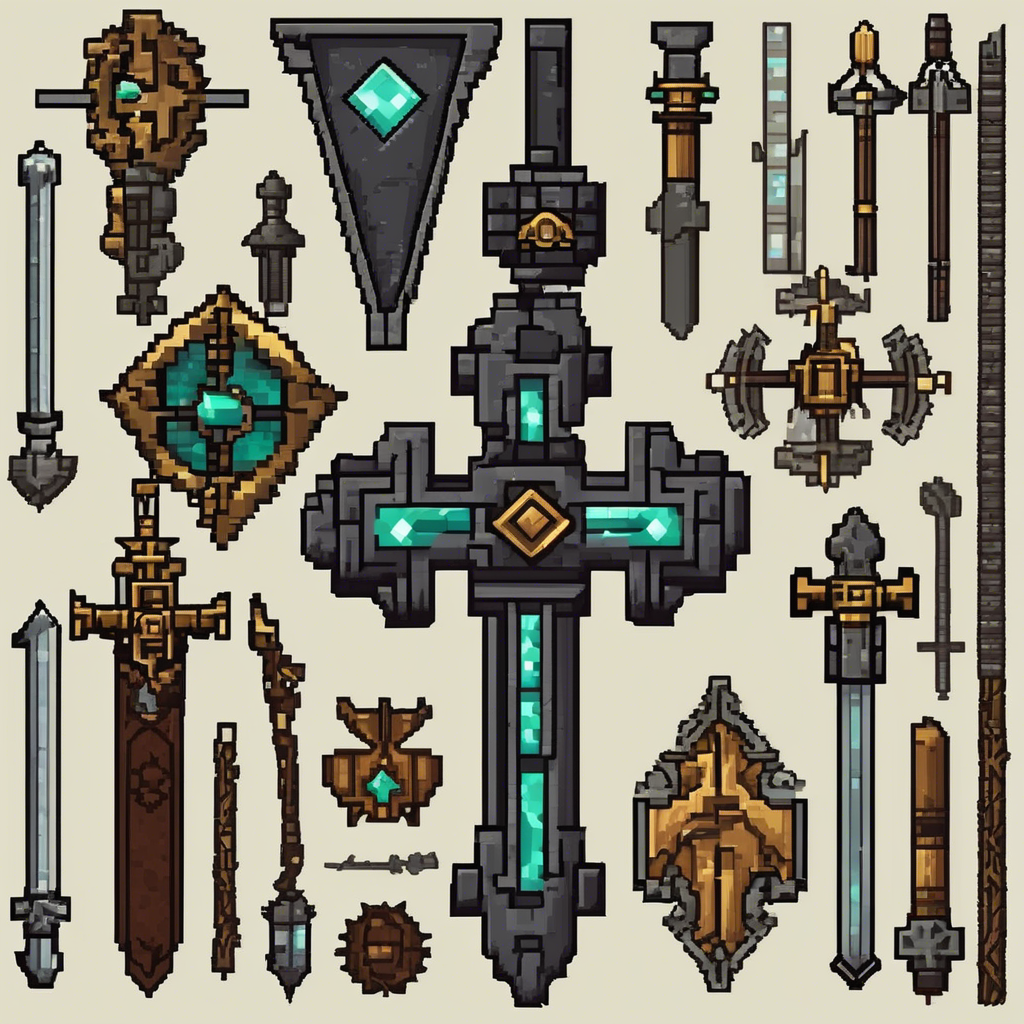

In [31]:
prompt = "minecraft texture pixel art, item, diamond sword, theme medieval dark steampunk industrial"
negative_promt = "blurry, realistic, photograph, 3d render"
image = pipe(prompt=prompt, negative_prompt=negative_promt).images[0]
image

### All-in-one

In [ ]:
snapshot_download(
    repo_id="PublicPrompts/All-In-One-Pixel-Model", local_dir=ALL_IN_ONE_MODEL_PATH
)

#### Text2Img

In [ ]:
pipe = DiffusionPipeline.from_pretrained(
    ALL_IN_ONE_MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
    safety_checker=None,
    requires_safety_checker=False,
)

  0%|          | 0/50 [00:00<?, ?it/s]

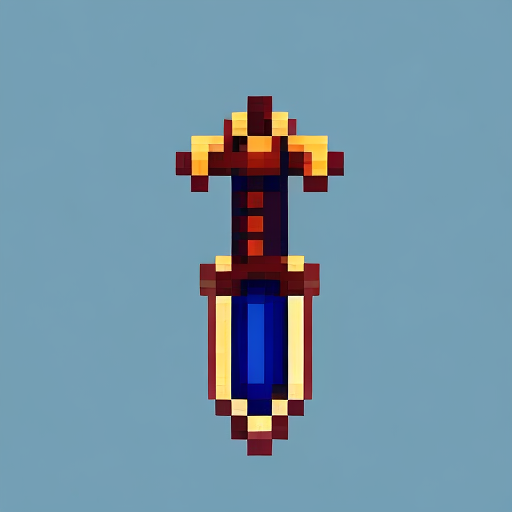

In [35]:
prompt = "pixelsprite Minecraft diamond sword"
image = pipe(prompt).images[0]
image

  0%|          | 0/50 [00:00<?, ?it/s]

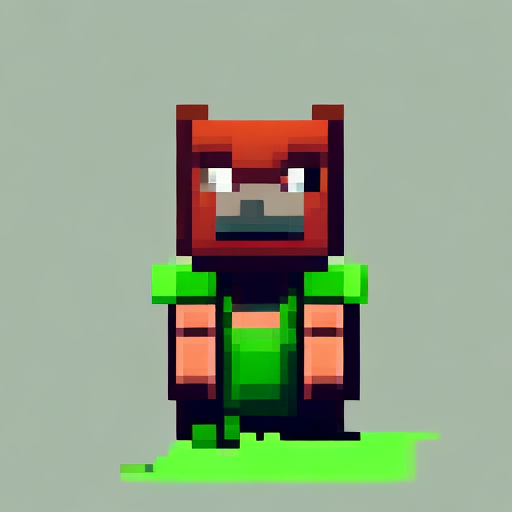

In [21]:
prompt = "pixelsprite Minecraft grass block"
image = pipe(prompt).images[0]
image

  0%|          | 0/50 [00:00<?, ?it/s]

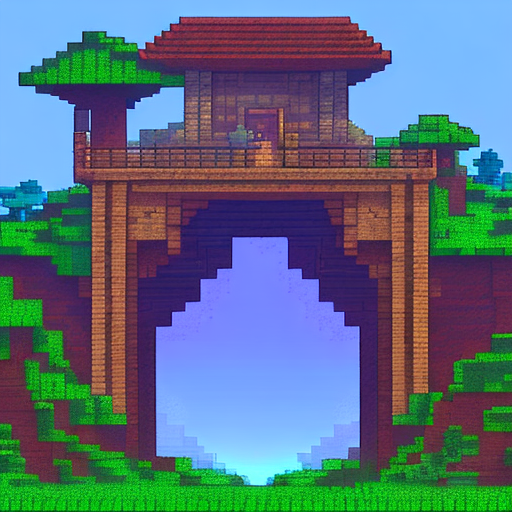

In [19]:
prompt = "16bitscene Minecraft diamond sword"
image = pipe(prompt).images[0]
image

  0%|          | 0/50 [00:00<?, ?it/s]

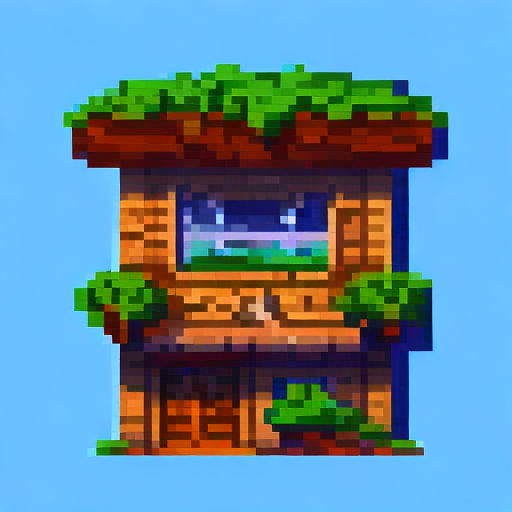

In [23]:
prompt = "pixelsprite Minecraft dirt block"
image = pipe(prompt).images[0]
image

In [ ]:
theme_prompt_query = """
Texture name: {texture_name}
Category: block, top face, 16x16 tileable
Theme style guide: Medieval
Generate a diffusion prompt to create this texture in this theme.
Rules:
- Must be seamlessly tileable
- Flat top-down view, no perspective
- No shadows, flat lighting
- Output ONLY the prompt string."""

prompt = "Top-down flat orthographic view of a medieval grass block texture, 16x16 pixel art style, seamlessly tileable, muted earthy green tones with hints of brown soil peeking through, coarse hand-painted grass blades, mossy patches, aged and weathered appearance, consistent flat lighting with no shadows, no perspective, no depth, square tile texture for Minecraft, pixel art, game asset"
image = pipe(prompt).images[0]
image

#### Img2Img

In [ ]:
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    ALL_IN_ONE_MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
    safety_checker=None,
    requires_safety_checker=False,
)

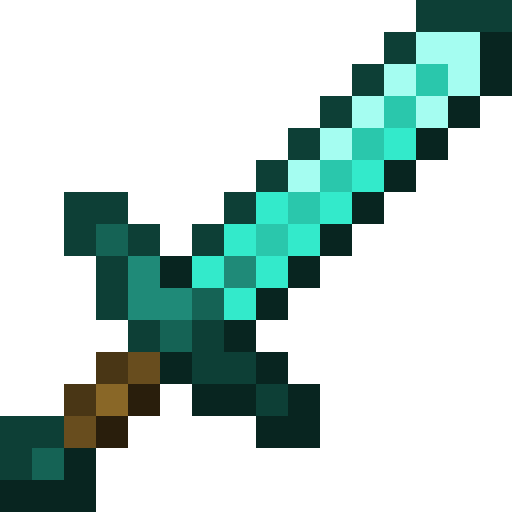

In [ ]:
init_image = get_texture_image("./default-texture-pack", "item/diamond_sword.png")
init_image = init_image.resize((512, 512), resample=Image.NEAREST)
init_image

  0%|          | 0/50 [00:00<?, ?it/s]

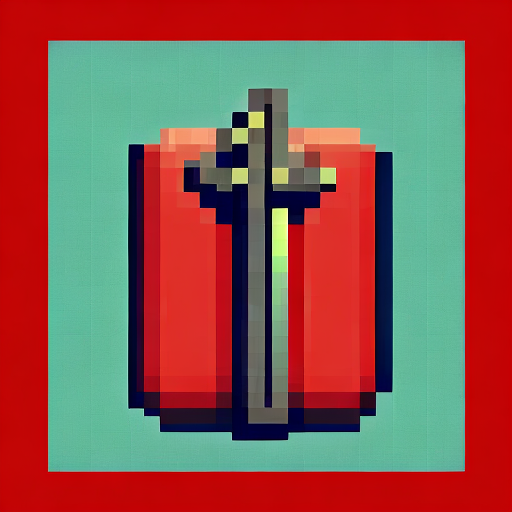

In [39]:
prompt = "pixelsprite Minecraft sword in red"
image = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.5,  # 0.0 = original, 1.0 =
    # guidance_scale=7.5,
).images[0]
image

### Minecraft Texture

#### Text2Img

In [ ]:
snapshot_download(
    repo_id="sd-research/stable-diffusion-2-1-base", local_dir=SD2_1_MODEL_PATH
)

os.makedirs(MINECRAFT_TEXTURE_LORA_MODEL_PATH, exist_ok=True)
files = {
    "Minecraft-Textures-LoRA-V1.0.safetensors": "https://github.com/Jack-Bagel/Minecraft-Lora-Training/raw/main/model/Minecraft-Textures-LoRA-V1.0.safetensors",
    "Minecraft-Textures-Properties-V1.0.yaml": "https://github.com/Jack-Bagel/Minecraft-Lora-Training/raw/main/model/Minecraft-Textures-Properties-V1.0.yaml",
    "basic_lora_config.json": "https://github.com/Jack-Bagel/Minecraft-Lora-Training/raw/main/basic_lora_config.json",
}
for filename, url in files.items():
    dest = os.path.join(MINECRAFT_TEXTURE_LORA_MODEL_PATH, filename)
    print(f"Downloading {filename}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()
    with open(dest, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"{filename} saved to {dest}")

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(
    SD2_1_MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
    safety_checker=None,
    requires_safety_checker=False,
)

pipe.load_lora_weights(
    MINECRAFT_TEXTURE_LORA_MODEL_PATH,
    weight_name="Minecraft-Textures-LoRA-V1.0.safetensors",
)

  0%|          | 0/50 [00:00<?, ?it/s]

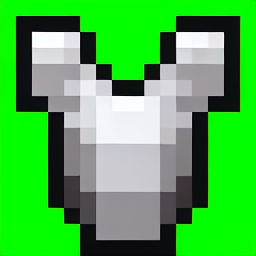

In [24]:
image = pipe(
    prompt="Chestplate",
    height=256,
    width=256,
    num_inference_steps=50,
    # guidance_scale=7.5
).images[0]
image

166.01 ms


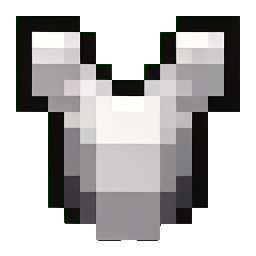

In [25]:
import time

current = time.time()
image = remove_background(image)
print(f"{(time.time() - current) * 1000:.2f} ms")
image

  0%|          | 0/50 [00:00<?, ?it/s]

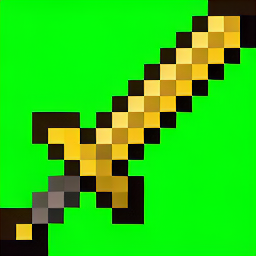

In [17]:
image = pipe(
    prompt="Medieval Gold sword",
    height=256,
    width=256,
    num_inference_steps=50,
    # guidance_scale=7.5
).images[0]
image

  0%|          | 0/50 [00:00<?, ?it/s]

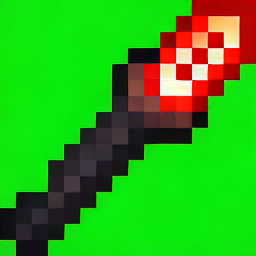

In [ ]:
image = pipe(
    prompt="Medieval red torch",
    height=256,
    width=256,
    num_inference_steps=50,
    # guidance_scale=7.5
).images[0]
image

  0%|          | 0/50 [00:00<?, ?it/s]

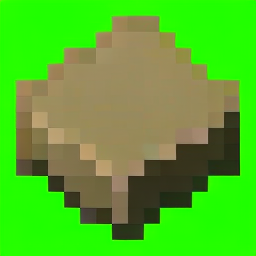

In [ ]:
prompt = "Top-down flat square view of a dirt block with consistent flat lighting with no shadows, no perspective, no depth, square tile texture for Minecraft"
image = pipe(
    prompt=prompt,
    height=256,
    width=256,
    num_inference_steps=50,
    # guidance_scale=7.5
).images[0]
image

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['pixel art , game asset']


  0%|          | 0/50 [00:00<?, ?it/s]

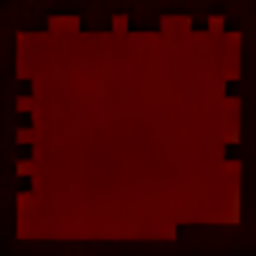

In [16]:
prompt = "Top-down flat square view of a grass block texture, 16x16 pixel art style, seamlessly tileable, muted earthy green tones with hints of brown soil peeking through, coarse hand-painted grass blades, mossy patches, aged and weathered appearance, consistent flat lighting with no shadows, no perspective, no depth, square tile texture for Minecraft, pixel art, game asset"
image = pipe(
    prompt=prompt,
    height=256,
    width=256,
    num_inference_steps=50,
    # guidance_scale=7.5
).images[0]
image

  0%|          | 0/50 [00:00<?, ?it/s]

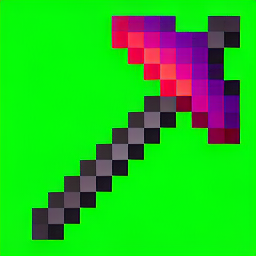

In [67]:
prompt = "umbrella"
image = pipe(
    prompt=prompt,
    height=256,
    width=256,
    num_inference_steps=50,
    # guidance_scale=7.5
).images[0]
image

  0%|          | 0/50 [00:00<?, ?it/s]

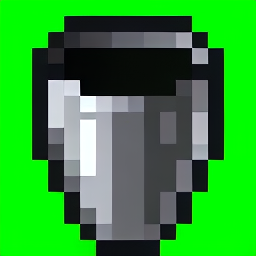

In [10]:
prompt = "Dark bucket"
image = pipe(
    prompt=prompt,
    height=256,
    width=256,
    num_inference_steps=50,
    # guidance_scale=7.5
).images[0]
image

#### Img2Img

In [ ]:
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    SD2_1_MODEL_PATH,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
).to("cuda")

pipe.load_lora_weights(
    MINECRAFT_TEXTURE_LORA_MODEL_PATH,
    weight_name="Minecraft-Textures-LoRA-V1.0.safetensors",
)

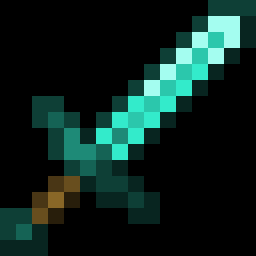

In [45]:
init_image = get_texture_image(DEFAULT_TEXTURE_PACK_ZIP_PATH, "item/diamond_sword.png")
init_image = init_image.convert("RGB")
init_image = init_image.resize((256, 256), resample=Image.NEAREST)
init_image

  0%|          | 0/37 [00:00<?, ?it/s]

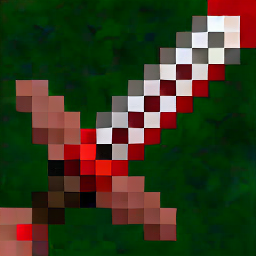

In [56]:
image = pipe(
    prompt="minecraft texture, sword in red",
    image=init_image,
    strength=0.75,
    guidance_scale=7.5,
    num_inference_steps=50,
).images[0]
image

### Plixel Minecraft

In [ ]:
os.makedirs(PLIXEL_MINECRAFT_MODEL_PATH, exist_ok=True)
weight_file = "Plixel-SD-1.5.safetensors"
local_weight_path = hf_hub_download(
    repo_id="OVAWARE/plixel-minecraft",
    filename=weight_file,
    local_dir=PLIXEL_MINECRAFT_MODEL_PATH,
)

In [ ]:
os.makedirs(PRETRAINED_MODEL_PATH_HOST, exist_ok=True)
snapshot_download(
    repo_id="stable-diffusion-v1-5/stable-diffusion-v1-5",
    local_dir=PRETRAINED_MODEL_PATH_HOST,
)

In [ ]:
pipeline = StableDiffusionPipeline.from_pretrained(
    PRETRAINED_MODEL_PATH_HOST,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
).to("cuda")

pipeline.load_lora_weights(
    PLIXEL_MINECRAFT_MODEL_PATH,
    weight_name="Plixel-SD-1.5.safetensors",
)

  0%|          | 0/30 [00:00<?, ?it/s]

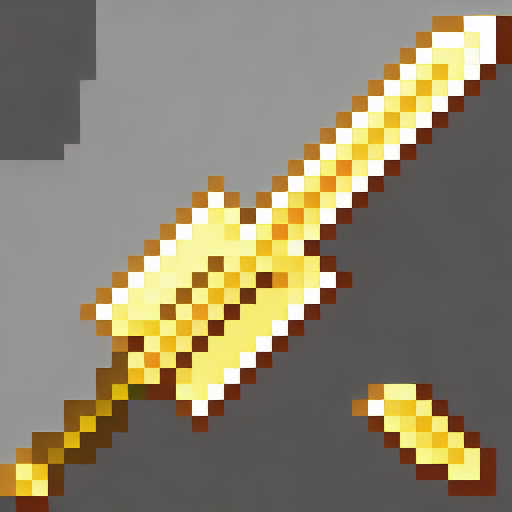

In [13]:
prompt = "Medieval gold sword"
image = pipeline(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]
image

  0%|          | 0/30 [00:00<?, ?it/s]

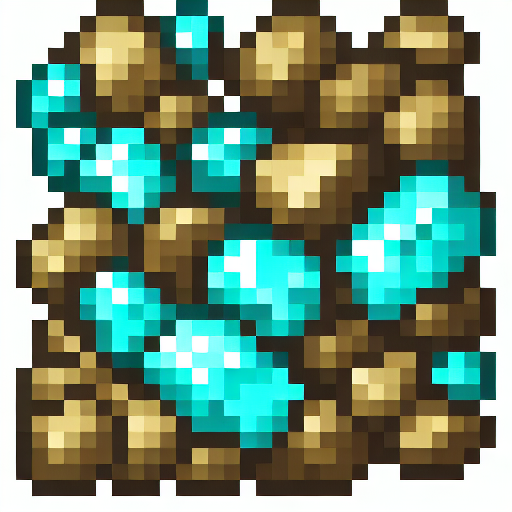

In [ ]:
prompt = "Diamond ore"
image = pipeline(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]
image

  0%|          | 0/30 [00:00<?, ?it/s]

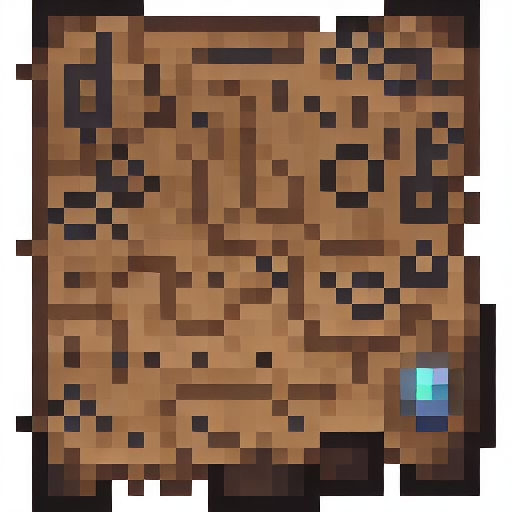

In [16]:
prompt = "Steampunk pack favicon"
image = pipeline(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]
image

  0%|          | 0/30 [00:00<?, ?it/s]

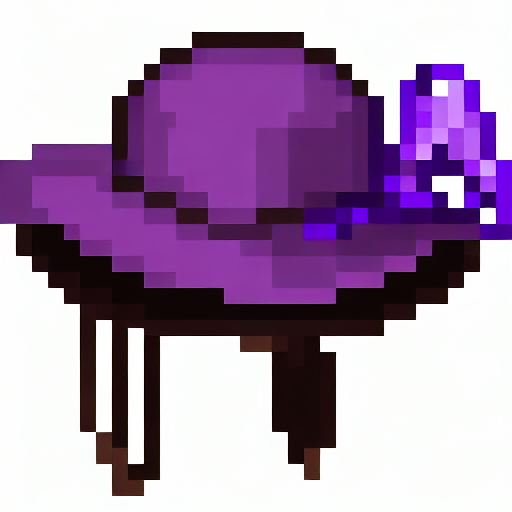

In [18]:
prompt = "Steampunk purple hat"
image = pipeline(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]
image

  0%|          | 0/30 [00:00<?, ?it/s]

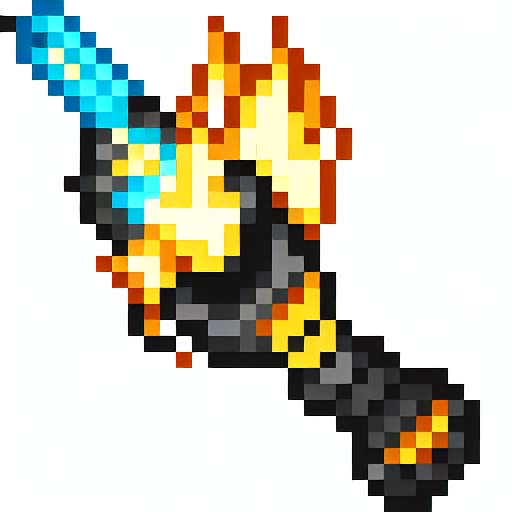

In [23]:
prompt = "Hand Torch"
image = pipeline(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]
image

  0%|          | 0/30 [00:00<?, ?it/s]

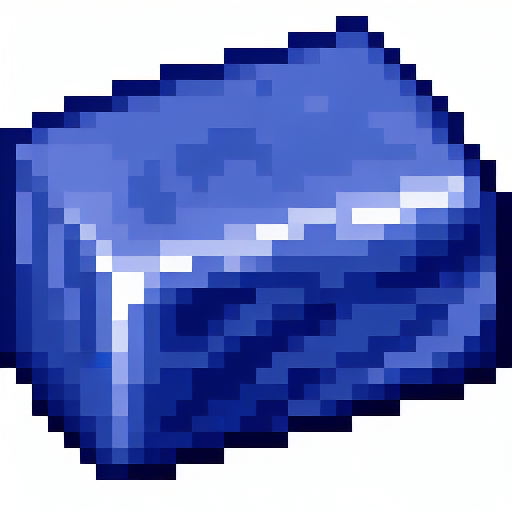

In [24]:
prompt = "Lapis ingot"
image = pipeline(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]
image

  0%|          | 0/30 [00:00<?, ?it/s]

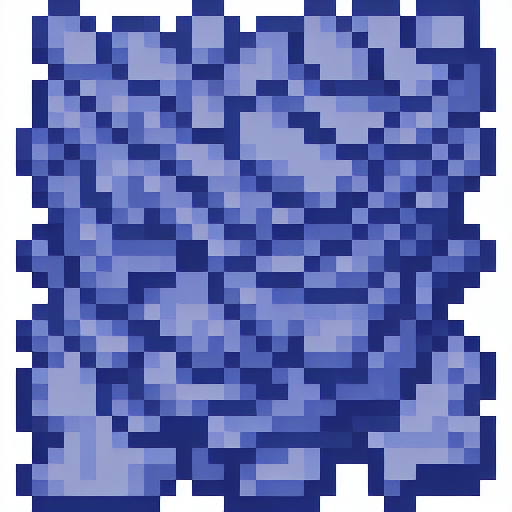

In [25]:
prompt = "Lapis block top-down texture"
image = pipeline(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]
image

  0%|          | 0/30 [00:00<?, ?it/s]

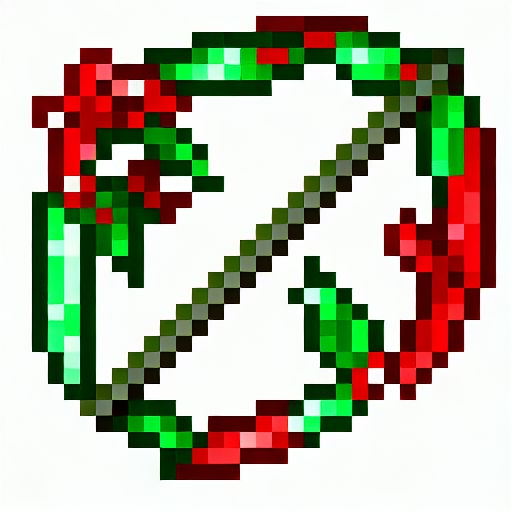

In [ ]:
prompt = "Christmas pickaxe"
image = pipeline(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]
image